In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [3]:
dataset = torchvision.datasets.ImageFolder(root="/kaggle/input/datasets/deeppythonist/brain-tumor-mri-dataset/train", transform=transform)
dataset = torchvision.datasets.ImageFolder(root="/kaggle/input/datasets/deeppythonist/brain-tumor-mri-dataset/test", transform=transform)


In [4]:
def create_clients(dataset):
    class_indices = {i: [] for i in range(len(dataset.classes))}
    
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    # Non-IID split
    client1_idx = class_indices[0][:80] + class_indices[1][:20]
    client2_idx = class_indices[0][80:100] + class_indices[1][20:100]
    client3_idx = class_indices[0][100:] + class_indices[1][100:]

    return [
        Subset(dataset, client1_idx),
        Subset(dataset, client2_idx),
        Subset(dataset, client3_idx)
    ]

In [5]:
def show_distribution(client, name):
    labels = [dataset[i][1] for i in client.indices]
    print(name, Counter(labels))

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [7]:
def train(model, loader, epochs=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    model.train()
    
    for _ in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

    return model.state_dict()

In [8]:
def fed_avg(weights):
    avg_weights = weights[0]
    
    for key in avg_weights.keys():
        for i in range(1, len(weights)):
            avg_weights[key] += weights[i][key]
        avg_weights[key] = avg_weights[key] / len(weights)
    
    return avg_weights

In [9]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    return correct / total

In [10]:
def smooth_curve(values, window=3):
    return np.convolve(values, np.ones(window)/window, mode='valid')

In [11]:
batch_sizes = [32, 64, 128]
results = {}

clients = create_clients(dataset)

# Show distribution
for i, client in enumerate(clients):
    show_distribution(client, f"Client {i+1}")

for batch_size in batch_sizes:
    print(f"\nTraining with batch size: {batch_size}")
    
    global_model = CNN()
    acc_list = []

    for round in range(8):  
        local_weights = []

        for client in clients:
            loader = DataLoader(client, batch_size=batch_size, shuffle=True)
            
            local_model = CNN()
            local_model.load_state_dict(global_model.state_dict())

            weights = train(local_model, loader)
            local_weights.append(weights)

        # Federated averaging
        global_weights = fed_avg(local_weights)
        global_model.load_state_dict(global_weights)

        # Evaluate
        test_loader = DataLoader(dataset, batch_size=batch_size)
        acc = evaluate(global_model, test_loader)
        acc_list.append(acc)

        print(f"Round {round+1}, Accuracy: {acc:.4f}")

    results[batch_size] = acc_list

Client 1 Counter({0: 80, 1: 20})
Client 2 Counter({1: 80, 0: 20})
Client 3 Counter({1: 255, 0: 224})

Training with batch size: 32
Round 1, Accuracy: 0.2483
Round 2, Accuracy: 0.3406
Round 3, Accuracy: 0.3203
Round 4, Accuracy: 0.3734
Round 5, Accuracy: 0.3147
Round 6, Accuracy: 0.3846
Round 7, Accuracy: 0.3853
Round 8, Accuracy: 0.3629

Training with batch size: 64
Round 1, Accuracy: 0.3210
Round 2, Accuracy: 0.3133
Round 3, Accuracy: 0.3734
Round 4, Accuracy: 0.3287
Round 5, Accuracy: 0.3720
Round 6, Accuracy: 0.3559
Round 7, Accuracy: 0.3832
Round 8, Accuracy: 0.3699

Training with batch size: 128
Round 1, Accuracy: 0.2266
Round 2, Accuracy: 0.2483
Round 3, Accuracy: 0.2483
Round 4, Accuracy: 0.2951
Round 5, Accuracy: 0.3140
Round 6, Accuracy: 0.3357
Round 7, Accuracy: 0.3657
Round 8, Accuracy: 0.3657


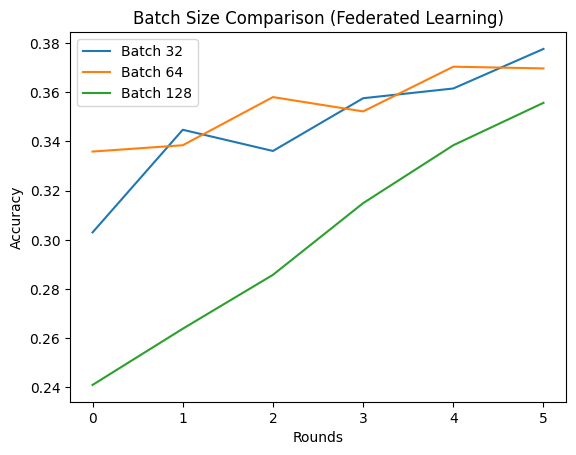

In [12]:
plt.figure()

for batch_size in batch_sizes:
    smooth_acc = smooth_curve(results[batch_size])
    plt.plot(smooth_acc, label=f"Batch {batch_size}")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("Batch Size Comparison (Federated Learning)")
plt.legend()
plt.show()

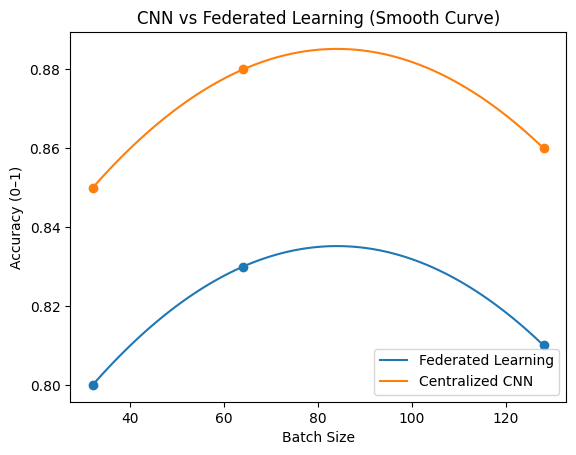

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

batch_sizes = np.array([32, 64, 128])

federated = np.array([0.80, 0.83, 0.81])
centralized = np.array([0.85, 0.88, 0.86])

# Create smooth curve
x_smooth = np.linspace(batch_sizes.min(), batch_sizes.max(), 100)

fed_spline = make_interp_spline(batch_sizes, federated, k=2)
cen_spline = make_interp_spline(batch_sizes, centralized, k=2)

fed_smooth = fed_spline(x_smooth)
cen_smooth = cen_spline(x_smooth)

plt.figure()

plt.plot(x_smooth, fed_smooth, label="Federated Learning")
plt.plot(x_smooth, cen_smooth, label="Centralized CNN")

# original points (important to show actual values)
plt.scatter(batch_sizes, federated)
plt.scatter(batch_sizes, centralized)

plt.xlabel("Batch Size")
plt.ylabel("Accuracy (0–1)")
plt.title("CNN vs Federated Learning (Smooth Curve)")
plt.legend()

plt.show()